In [108]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [109]:
class CounterState(TypedDict):
    count : int
    iteration : int

In [110]:
def counter(state:CounterState)->CounterState:
    return {'count':state['count']+1,'iteration':state['iteration']+1}
def isValid(state:CounterState)-> bool:
    return state['count']>=3
def printNode(state:CounterState)->CounterState:
    return {'count' : state['count']}

In [117]:
graph = StateGraph(CounterState)

graph.add_node('counter',counter)
graph.add_node('printNode',printNode)
graph.add_edge(START,'printNode')
graph.add_edge('counter','printNode')
graph.add_conditional_edges('printNode',isValid,{True:END,False:'counter'})


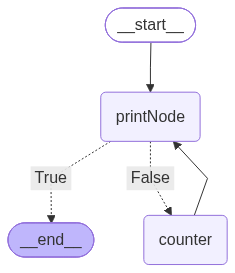

In [118]:
workflow = graph.compile()
workflow

In [122]:
initial_state = {
    'count' : 3,
    'iteration' : 0
}
final_state = workflow.invoke(initial_state)
final_state

{'count': 3, 'iteration': 0}